In [1]:
import pandas as pd
import numpy as np

import time

from PIL import Image
# import ot
import os
import glob
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from gpcam import GPOptimizer
from scipy.spatial.distance import cdist



# Load Data

In [ ]:
# ── Load images ─────────────────────────────────────────
IMAGE_DIR        = 'Data/images'
all_paths   = sorted(glob.glob(os.path.join(IMAGE_DIR, '*.png')))

# ── Load distance matrices ──────────────────────────────
wd_filename  = 'Data/wasserstein_distances_full.npy'
swd_filename = 'Data/sliced_wasserstein_distances_full.npy'

WD_matrix  = np.load(wd_filename)
SWD_matrix = np.load(swd_filename)

# ── output ───────────────────────────────────────────────
y = np.load('Data/y_modulus.npy')

# Seperating Training and Testing Data

In [4]:

# ── Choose metric ─────────────────────────────────────────────────────────────

distance_full = SWD_matrix # Choose between WD_matrix and SWD_matrix

# ── Indices as X ──────────────────────────────────────────────────────────────
indices = np.arange(len(y))   # [0, 1, 2, ..., 19]

# ── Split ─────────────────────────────────────────────────────────────────────
x_train, x_test, y_train, y_test = train_test_split(
    indices, y,
    # test_size=0.3,      # 80/20 split → 16 train, 4 test for 20 images
    train_size=250,      # exactly 250 random training points
    random_state=3345
)

x_train = x_train.reshape(-1,1)
x_test = x_test.reshape(-1,1)

print('Done')
x_train.shape

Done


(250, 1)

# GP Model

In [5]:
# Step 2: Define the basic GP components

def matern_kernel_diff1(distance, length):
    kernel = (1.0 + ((np.sqrt(3.0) * distance) / length)) * np.exp(
        -(np.sqrt(3.0) * distance) / length
    )
    return kernel

def bump(d, r, beta, ampl):
    a = 1.0 - (d**2 / r**2)
    bump_values = np.zeros_like(a)
    
    # Only compute where a > 0
    positive_mask = a > 0.0
    if np.any(positive_mask):
        #beta = 0.1
        e = np.exp((-beta / a[positive_mask]) + beta)
        bump_values[positive_mask] = ampl * e
    
    return bump_values


def bump_k(x1, x2, hps):
    
    # x1 and x2 ARE the indices - just extract them
    x1_idx = x1.astype(int).flatten()
    x2_idx = x2.astype(int).flatten()
    
    d1 = distance_full[np.ix_(x1_idx, x_train.flatten())]  # Shape: (len(x1), n_train)
    d2 = distance_full[np.ix_(x2_idx, x_train.flatten())]  # Shape: (len(x2), n_train)
    
    # Apply bump to create embedding
    phi_x1 = bump(d1, hps[1], beta=1, ampl=hps[2])  # Shape: (len(x1), n_train)
    phi_x2 = bump(d2, hps[1], beta=1, ampl=hps[2])  # Shape: (len(x2), n_train)
    
    # RBF on embeddings
    D_mat = cdist(phi_x1, phi_x2, metric='euclidean')  # Shape: (len(x1), len(x2))
    
    kernel_matrix = hps[0] * matern_kernel_diff1(D_mat, hps[3])
    
    return kernel_matrix


def my_noise(x, hps):
    s = np.ones(len(x)) * hps[4] # FIXED: was 10^-5
    return np.diag(s)

def my_mean(x, hps):
    m = np.ones(len(x)) * hps[5]
    return m

In [6]:
# 2. Bump radius (hps[1]): [min distance, maximum distance]
train_geodesic = distance_full[np.ix_(x_train.flatten(), x_train.flatten())]
non_zero_dists = train_geodesic[train_geodesic > 0]

# Define hyperparameter bounds
bounds = np.empty((6, 2))
bounds[0] = np.array([1e-0, 1e10])   # 1                                           # sigma_f: signal variance      
bounds[1] = np.array([np.min(non_zero_dists), 2* np.max(non_zero_dists)])       # length_scale: bump radius
bounds[2] = np.array([0.01, 10 ])# 2                                         
bounds[3] = np.array([0.01 * bounds[2,0], 10 * bounds[2,1]])               # length_scale for RBF on embeddings 
bounds[4] = np.array([1e-5, 10 ])                                             # mean function offset         
bounds[5] = np.array([np.min(y), np.max(y) ])                                             # mean function offset         

print(f"\nHyperparameter bounds:")
print(f"  Signal variance: [{bounds[0, 0]:.6f}, {bounds[0, 1]:.6f}]")
print(f"  Bump radius:     [{bounds[1, 0]:.6f}, {bounds[1, 1]:.6f}]")
print(f"  Bump amplit:     [{bounds[2, 0]:.6f}, {bounds[2, 1]:.6f}]")
print(f"  RBF length:      [{bounds[3, 0]:.6f}, {bounds[3, 1]:.6f}]")
print(f"  Noise:           [{bounds[4, 0]:.6f}, {bounds[4, 1]:.6f}]")
print(f"  Mean:            [{bounds[5, 0]:.6f}, {bounds[5, 1]:.6f}]")


Hyperparameter bounds:
  Signal variance: [1.000000, 10000000000.000000]
  Bump radius:     [0.002786, 0.255216]
  Bump amplit:     [0.010000, 10.000000]
  RBF length:      [0.000100, 100.000000]
  Noise:           [0.000010, 10.000000]
  Mean:            [1.000002, 8.999981]


In [ ]:
import time
# Initial hyperparameters (middle of bounds)
init_hps = np.mean(bounds, axis=1)
print(f"\nInitial hyperparameters: {init_hps}")

my_gpo = GPOptimizer(x_train, y_train,
                     init_hyperparameters=init_hps,
                     kernel_function=bump_k,
                     prior_mean_function=my_mean, 
                     noise_function=my_noise,
                        )

initial_log_likelihood = my_gpo.log_likelihood(init_hps)
print(f"Initial log likelihood: {initial_log_likelihood:.6f}")

# Step 5: Train the GP model
t0 = time.time()
my_gpo.train(hyperparameter_bounds=bounds, init_hyperparameters=init_hps, method='global', max_iter=10000)
t1 = time.time()
print(f"Training completed in {t1 - t0:.2f} seconds.")

# Get optimized hyperparameters
final_hps = my_gpo.get_hyperparameters()
final_ll = my_gpo.log_likelihood(final_hps)
print(f"Final hyperparameters:   {final_hps}")
print(f"Final log likelihood:    {final_ll:.2f}")

RMSE: 0.3037539924368189


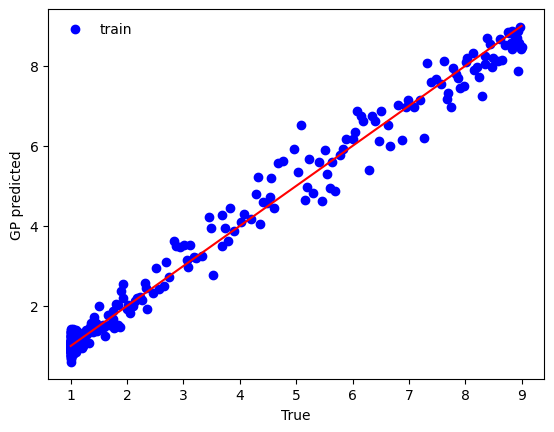

In [ ]:
t0 = time.time()
f_train = my_gpo.posterior_mean(x_train)["m(x)"]
t1 = time.time()
print(f"Posterior mean computed in {t1 - t0:.2f} seconds.")

my_line = np.linspace(np.min(y_train),np.max(y_train),10)

print('RMSE:', my_gpo.rmse(x_train,y_train)) # *100/np.mean(y_train),'%')

plt.scatter(y_train,f_train,color="blue",label = 'train')
plt.plot(my_line,my_line,c="red")
plt.xlabel("True")
plt.ylabel("GP predicted")
plt.legend(frameon = False)
plt.show()

RMSE: 0.5452171902033626


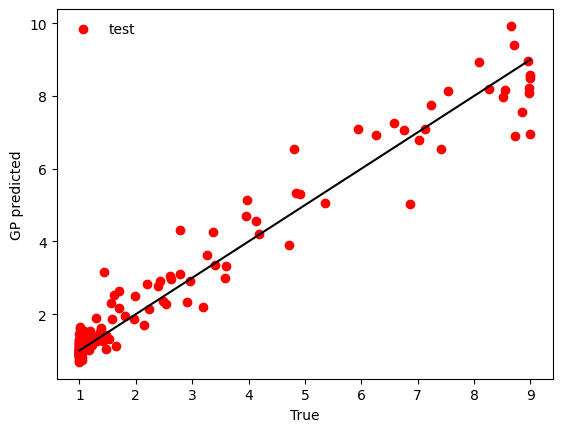

In [11]:
f = my_gpo.posterior_mean(x_test)["m(x)"]
posterior_var = my_gpo.posterior_covariance(x_test, variance_only=True, add_noise=False) # it does not matter if we added noise because it is 1e-6
var = posterior_var["v(x)"].flatten()

print('RMSE:', my_gpo.rmse(x_test,y_test)) # *100/np.mean(y_train),'%')

my_line = np.linspace(np.min(y_test),np.max(y_train),10)

plt.scatter(y_test,f,color="red",label = 'test')
plt.plot(my_line,my_line,c="black")
plt.xlabel("True")
plt.ylabel("GP predicted")
plt.legend(frameon = False)
plt.show()

# Multiple GPs

In [1]:
import numpy as np
import random
import json
from tqdm import tqdm
from gpcam import GPOptimizer
import os
import time as _time

from scipy.spatial.distance import cdist

from scipy.stats import norm



In [ ]:
# ── Load distance matrices ───────────────────────────────────────────────
wd_filename  = 'Data/wasserstein_distances_full.npy'
swd_filename = 'Data/sliced_wasserstein_distances_full.npy'

WD_matrix  = np.load(wd_filename)
SWD_matrix = np.load(swd_filename)

ground_truth = np.load('Data/y_modulus.npy')

distance_full = WD_matrix # Choose between WD_matrix and SWD_matrix


In [4]:
# import numpy as np
# import json

# # ---- CONFIG ----
# N_total = 500                         # total number of SAXS images
# n_test = 100                          # held-out test set size
# training_sizes = [150, 200, 250]      # match what your run script actually loops over
# n_trials_per_size = 100               # number of random initializations per size
# master_seed = 42                      # seed for generating this config file itself
# # -----------------

# rng = np.random.default_rng(master_seed)

# all_indices = np.arange(N_total)

# # 1. Fixed test set (held out once, shared across all training sizes/trials)
# test_indices = rng.choice(all_indices, size=n_test, replace=False)
# remaining_pool = np.setdiff1d(all_indices, test_indices)   # 400 indices available for training

# # 2. Training configurations
# training_configurations = {}

# for size in training_sizes:
#     trials = []
#     for trial_idx in range(n_trials_per_size):
#         seed = int(rng.integers(0, 100000))
#         trial_rng = np.random.default_rng(seed)
#         indices_train = trial_rng.choice(remaining_pool, size=size, replace=False)
#         trials.append({
#             "seed": seed,
#             "indices_train": indices_train.tolist()
#         })
#     training_configurations[str(size)] = trials

# configs = {
#     "test_indices": test_indices.tolist(),
#     "training_configurations": training_configurations
# }

# with open('saxs_training_configurations.json', 'w') as f:
#     json.dump(configs, f, indent=2)

# print(f"Test set size: {len(test_indices)}")
# print(f"Remaining pool for training: {len(remaining_pool)}")
# print(f"Training sizes generated: {training_sizes}, {n_trials_per_size} trials each")

In [5]:

def matern_kernel_diff1(distance, length):
    kernel = (1.0 + ((np.sqrt(3.0) * distance) / length)) * np.exp(
        -(np.sqrt(3.0) * distance) / length
    )
    return kernel

def bump(d, r, beta, ampl):
    a = 1.0 - (d**2 / r**2)
    bump_values = np.zeros_like(a)
    
    # Only compute where a > 0
    positive_mask = a > 0.0
    if np.any(positive_mask):
        #beta = 0.1
        e = np.exp((-beta / a[positive_mask]) + beta)
        bump_values[positive_mask] = ampl * e
    
    return bump_values


def bump_k(x1, x2, hps):
    
    # x1 and x2 ARE the indices - just extract them
    x1_idx = x1.astype(int).flatten()
    x2_idx = x2.astype(int).flatten()
    
    d1 = distance_full[np.ix_(x1_idx, x_train.flatten())]  # Shape: (len(x1), n_train)
    d2 = distance_full[np.ix_(x2_idx, x_train.flatten())]  # Shape: (len(x2), n_train)
    
    # Apply bump to create embedding
    phi_x1 = bump(d1, hps[1], beta=1, ampl=hps[2])  # Shape: (len(x1), n_train)
    phi_x2 = bump(d2, hps[1], beta=1, ampl=hps[2])  # Shape: (len(x2), n_train)
    
    # RBF on embeddings
    D_mat = cdist(phi_x1, phi_x2, metric='euclidean')  # Shape: (len(x1), len(x2))
    
    kernel_matrix = hps[0] * matern_kernel_diff1(D_mat, hps[3])
    
    return kernel_matrix


def my_noise(x, hps):
    s = np.ones(len(x)) * hps[4] # FIXED: was 10^-5
    return np.diag(s)

def my_mean(x, hps):
    m = np.ones(len(x)) * hps[5]
    return m

In [ ]:
def load_configurations(json_file_name):
    """Load the training configurations"""
    with open(json_file_name, 'r') as f:
        configs = json.load(f)
    return configs

def load_or_create_results_file(filename='gp_experiment_results.json'):
    """Load existing results or create new file"""
    if os.path.exists(filename):
        with open(filename, 'r') as f:
            try:
                existing_results = json.load(f)
                print(f"Loaded {len(existing_results)} existing results")
                return existing_results
            except:
                print("Creating new results file")
                return []
    else:
        print("Creating new results file")
        return []

def get_test_data(configs, ground_truth):
    """Get the fixed test data"""
    x_test = np.array(configs['test_indices']).reshape(-1,1)
    y_test = ground_truth[x_test].flatten()
    return x_test, y_test

def get_training_data(configs, training_size, trial_number, ground_truth):
    """Get training data for specific configuration"""
    
    trial = configs['training_configurations'][str(training_size)][trial_number]
    
    seed = trial['seed']
    
    indices_train = np.array(trial['indices_train'])        # ← assign first
    x_train       = indices_train.reshape(-1, 1)            # ← then reshape
    y_train       = ground_truth[indices_train]
    
    return x_train, y_train, seed, indices_train

def get_hps_bounds(indices_train):
    
    train_geodesic = distance_full[np.ix_(indices_train, indices_train)]
    non_zero_dists = train_geodesic[train_geodesic > 0]
    
    bounds = np.empty((6, 2))
    bounds[0] = np.array([1e-0, 1e10])                                            # sigma_f: signal variance      
    bounds[1] = np.array([np.min(non_zero_dists), 2* np.max(non_zero_dists)])       # length_scale: bump radius
    bounds[2] = np.array([0.01, 10 ])                                         
    bounds[3] = np.array([0.01 * bounds[2,0], 10 * bounds[2,1]])               # length_scale for RBF on embeddings 
    bounds[4] = np.array([1e-5, 10 ])                                             # mean function offset         
    bounds[5] = np.array([0, 10 ])                                             # mean function offset         
    
    return bounds

def train_gp_model(x_train, y_train, bounds):
    """Train GP model with your existing setup"""
    
    # Initial hyperparameters (middle of bounds)
    init_hps = np.mean(bounds, axis=1)
    
    # Initialize GPOptimizer
    my_gpo = GPOptimizer(x_train, y_train,
                         init_hyperparameters=init_hps,
                         kernel_function=bump_k,
                         prior_mean_function=my_mean, 
                         noise_function=my_noise)
    
    # Train the GP model
    my_gpo.train(hyperparameter_bounds=bounds, 
                 init_hyperparameters=init_hps, 
                 method='global', 
                 max_iter=10000)
    
    return my_gpo

def picp(gp_model_object, x_test, y_true, interval=0.95):
        mu = gp_model_object.posterior_mean(x_test)["m(x)"]
        sigma = np.sqrt(gp_model_object.posterior_covariance(x_test, add_noise=True)["v(x)"])

        z = norm.ppf(1 - (1 - interval) / 2)
        lower_bounds = mu - z * sigma
        upper_bounds = mu + z * sigma

        inside = (y_true >= lower_bounds) & (y_true <= upper_bounds)
        picp = np.mean(inside)

        return picp
   

def save_results_incremental(results, filename='gp_experiment_results.json'):
    """Save results incrementally"""
    with open(filename, 'w') as f:
        json.dump(results, f, indent=2)

def check_if_already_done(existing_results, train_size, trial_idx):
    """Check if this experiment was already completed"""
    for result in existing_results:
        if (result.get('training_size') == train_size and 
            result.get('trial') == trial_idx):
            return True
    return False

def run_complete_gp_experiments():
    """Run all GP experiments and save results incrementally"""
    
    # Load configurations
    print("Loading configurations...")
    json_file_name = 'Data/saxs_training_configurations.json'
    configs = load_configurations(json_file_name)
    
    # Load existing results or create new
    results_filename = 'Data/SLE_Sliced_Wass.json'
    all_results = load_or_create_results_file(results_filename)
    
    # Get fixed test data
    x_test, y_test = get_test_data(configs, ground_truth)
    print(f"Test data: {x_test.shape}")

    training_sizes = [150, 200, 250]
    
    # Main experiment loop
    for train_size in training_sizes:
        print(f"\n=== Training Size: {train_size} ===")
        
        trials = configs['training_configurations'][str(train_size)]
        
        #for trial_idx in tqdm(range(len(trials)), desc=f"Size {train_size}"):
        for trial_idx in tqdm(range(30), desc=f"Size {train_size}"):
    
            # Skip if already completed
            if check_if_already_done(all_results, train_size, trial_idx):
                print(f"Skipping trial {trial_idx} (already completed)")
                continue
            
            try:
                # Get training data for this trial
                x_train, y_train, seed, indices_train = get_training_data(configs, train_size, trial_idx, ground_truth)


                ##################
                # Make x_train global so kernel functions can access it
                globals()['x_train'] = x_train  
                globals()['y_train'] = y_train
                globals()['indices_train'] = indices_train  
                ##################
                
                # Identify the hps bounds
                bounds = get_hps_bounds(indices_train)

                # before train_gp_model call
                t0 = _time.time()

                # Train GP model
                my_gpo = train_gp_model(x_train, y_train, bounds)
                
                train_time = _time.time() - t0

                # Calculate training RMSE
                train_rmse = my_gpo.rmse(x_train, y_train)

                # Predict time                
                t0 = _time.time()
                f = my_gpo.posterior_mean(x_test)['m(x)']
                v = my_gpo.posterior_covariance(x_test, add_noise= True,variance_only=True)['v(x)']
                predict_time = _time.time() - t0

                # Calculate testing RMSE
                test_rmse = my_gpo.rmse(x_test, y_test)

                # Compute CRPS
                crps_test = my_gpo.crps(x_test, y_test)

                # Compute picp
                picp_test = picp(my_gpo, x_test, y_test)
                
                # Get final hyperparameters and log likelihood
                final_hps = my_gpo.get_hyperparameters()
                final_ll = my_gpo.log_likelihood(final_hps)
                
                # Store results
                result = {
                    'training_size': train_size,
                    'trial': trial_idx,
                    'seed': seed,
                    'train_rmse': float(train_rmse),
                    'test_rmse': float(test_rmse),
                    'test_crps mean': float(crps_test[0]),
                    'test_crps std': float(crps_test[1]),
                    'test_picp': float(picp_test),
                    'final_log_likelihood': float(final_ll),
                    'final_hyperparameters': final_hps.tolist(),
                    'n_training_points': len(x_train),
                    'train_time': train_time,
                    'predict_time': predict_time,
                }
                
                all_results.append(result)
                
                # Save after each trial
                save_results_incremental(all_results, results_filename)
                
                # Print progress for first few trials
                if trial_idx < 3:
                    print(f"Trial {trial_idx}: Train RMSE={train_rmse:.4f}, Test RMSE={test_rmse:.4f} Saved")
                
            except Exception as e:
                print(f"Trial {trial_idx} failed: {str(e)}")
                
                # Save failed result too
                failed_result = {
                    'training_size': train_size,
                    'trial': trial_idx,
                    'seed': trials[trial_idx]['seed'],
                    'error': str(e),
                    'status': 'failed',
                    'completed_at': time.strftime('%Y-%m-%d %H:%M:%S')
                }
                all_results.append(failed_result)
                save_results_incremental(all_results, results_filename)
                continue
    
    return all_results

print("Starting GP experiments...")
print("="*60)

# Run experiments
results = run_complete_gp_experiments()

print("="*60)
print(f"Completed! Total experiments: {len(results)}")

Starting GP experiments...
Loading configurations...
Creating new results file
Test data: (100, 1)

=== Training Size: 150 ===


Size 150:   0%|          | 0/30 [00:00<?, ?it/s]

Size 150:   3%|▎         | 1/30 [00:29<14:19, 29.63s/it]

Trial 0: Train RMSE=0.0005, Test RMSE=0.6810 Saved


Size 150:   7%|▋         | 2/30 [00:56<12:57, 27.77s/it]

...

Trial 1: Train RMSE=0.1001, Test RMSE=0.5932 Saved


Size 250:  10%|█         | 3/30 [04:56<48:37, 108.04s/it]

Trial 2: Train RMSE=0.0001, Test RMSE=0.6604 Saved


Size 250: 100%|██████████| 30/30 [39:30<00:00, 79.00s/it] 

Completed! Total experiments: 90
